In [ ]:
# Install required packages
%pip install torch torchvision numpy scikit-learn kagglehub matplotlib
# Now restart the kernel before running the rest of the code
print("Please restart the kernel before proceeding!")
%pip uninstall torch torchvision
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
print("эщкере")

Note: you may need to restart the kernel to use updated packages.
Please restart the kernel before proceeding!


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import time
import os
from torch.utils.data import DataLoader, random_split
import kagglehub

In [2]:
# Параметры
batch_size = 128
img_size = 224
num_epochs = 10
learn_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Преобразования для данных
transform_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


cpu


Path to dataset files: C:\Users\ro517\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Содержимое скачанной папки:
Папка: chest_xray
		—— chest_xray
		—— test
		—— train
		—— val
		—— __MACOSX
Найден путь к данным: C:\Users\ro517\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray
Размер тренировочной выборки: 4172
Размер валидационной выборки: 1044
Размер тестовой выборки: 624


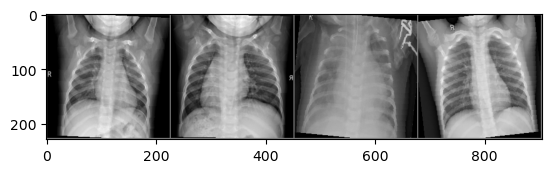

Метки: NORMAL NORMAL PNEUMONIA NORMAL


In [3]:
# Загрузка датасета
# Загрузка тренировочной и тестовой выборок
data_dir = "chest_xray"

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

# Проверим структуру скачанной папки
print("Содержимое скачанной папки:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"Папка: {item}")
        # Покажем подпапки
        for subitem in os.listdir(item_path):
            print(f"\t\t—— {subitem}")
def find_data_path(base_path):
    """Находит правильный путь к данным в скачанной структуре"""
    possible_paths = [
        base_path,
        os.path.join(base_path, "chest_xray"),
        os.path.join(base_path, "dataset"),
        os.path.join(base_path, "data")
    ]

    for test_path in possible_paths:
        train_path = os.path.join(test_path, "train")
        if os.path.exists(train_path):
            print(f"Найден путь к данным: {test_path}")
            return test_path

    # Если не нашли стандартную структуру, поищем любую папку с train и test
    for root, dirs, files in os.walk(base_path):
        if "train" in dirs and "test" in dirs:
            print(f"Найден альтернативный путь к данным: {root}")
            return root

    raise FileNotFoundError("Не удалось найти папки train и test в скачанном датасете")

# Находим правильный путь к данным
data_dir = find_data_path(path)

# Тренировочные данные
trainset = datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=transform_train
)

# Тестовые данные
testset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    transform=transform_test
)

# Разделяем тренировочные данные на train/val (80/20)
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size])

# Создание DataLoader для батчевой загрузки
trainloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
# Названия классов
classes = ('NORMAL', 'PNEUMONIA')

print(f"Размер тренировочной выборки: {len(train_subset)}")
print(f"Размер валидационной выборки: {len(val_subset)}")
print(f"Размер тестовой выборки: {len(testset)}")

def imshow(img):
    img = img / 2 + 0.5  # Денормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Показываем примеры изображений
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))
print('Метки:', ' '.join(f'{classes[labels[j]]}' for j in range(4)))

In [4]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            # Первый сверточный блок
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Второй сверточный блок
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Третий сверточный блок
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))  # Добавляем для уменьшения размерности
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * 7 * 7, 128),  # Значительно уменьшили размер
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [5]:
# Создание модели
cnn_model = CNNModel().to(device)
print("Базовая CNN модель:")
print(cnn_model)

Базовая CNN модель:
CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [6]:
def train_model_fast(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        # Режим обучения
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()  # Исправлено: добавлен .item()
            total_samples += inputs.size(0)

        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects / total_samples  # Теперь это обычное число, а не тензор

        # Валидация
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data).item()  # Исправлено: добавлен .item()
                val_total_samples += inputs.size(0)

        val_epoch_loss = val_running_loss / val_total_samples
        val_epoch_acc = val_running_corrects / val_total_samples

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {round(epoch_loss, 4)}, Train Acc: {round(epoch_acc, 4)}')
        print(f'Val Loss: {round(val_epoch_loss, 4)}, Val Acc: {round(val_epoch_acc, 4)}')

    return train_losses, train_accs, val_losses, val_accs

In [7]:
# Функция для оценки модели
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Вычисление метрик
    accuracy = accuracy_score(all_labels, all_preds)

    # Матрица ошибок
    cm = confusion_matrix(all_labels, all_preds)

    # Чувствительность и специфичность
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  # Recall для класса 1 (пневмония)
    specificity = tn / (tn + fp)  # Recall для класса 0 (норма)

    print(f"Accuracy: {round(accuracy, 4)}")
    print(f"Sensitivity (Recall): {round(sensitivity, 4)}")
    print(f"Specificity: {round(specificity, 4)}")
    print("\nМатрица ошибок:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_preds, all_labels, all_probs, cm


Обучение базовой CNN модели...
Epoch [1/10]
Train Loss: 0.5443, Train Acc: 0.7397
Val Loss: 0.3561, Val Acc: 0.749
Epoch [2/10]
Train Loss: 0.3267, Train Acc: 0.767
Val Loss: 0.2406, Val Acc: 0.9205
Epoch [3/10]
Train Loss: 0.2572, Train Acc: 0.8878
Val Loss: 0.1934, Val Acc: 0.9435
Epoch [4/10]
Train Loss: 0.2133, Train Acc: 0.9135
Val Loss: 0.1722, Val Acc: 0.9473
Epoch [5/10]
Train Loss: 0.1988, Train Acc: 0.9214
Val Loss: 0.135, Val Acc: 0.9559
Epoch [6/10]
Train Loss: 0.182, Train Acc: 0.9346
Val Loss: 0.1216, Val Acc: 0.9646
Epoch [7/10]
Train Loss: 0.1763, Train Acc: 0.9314
Val Loss: 0.1115, Val Acc: 0.9665
Epoch [8/10]
Train Loss: 0.1656, Train Acc: 0.9413
Val Loss: 0.1221, Val Acc: 0.955
Epoch [9/10]
Train Loss: 0.1655, Train Acc: 0.9394
Val Loss: 0.1257, Val Acc: 0.954
Epoch [10/10]
Train Loss: 0.1546, Train Acc: 0.9468
Val Loss: 0.1036, Val Acc: 0.9713
Обучение базовой CNN завершено за 1082.46 секунд


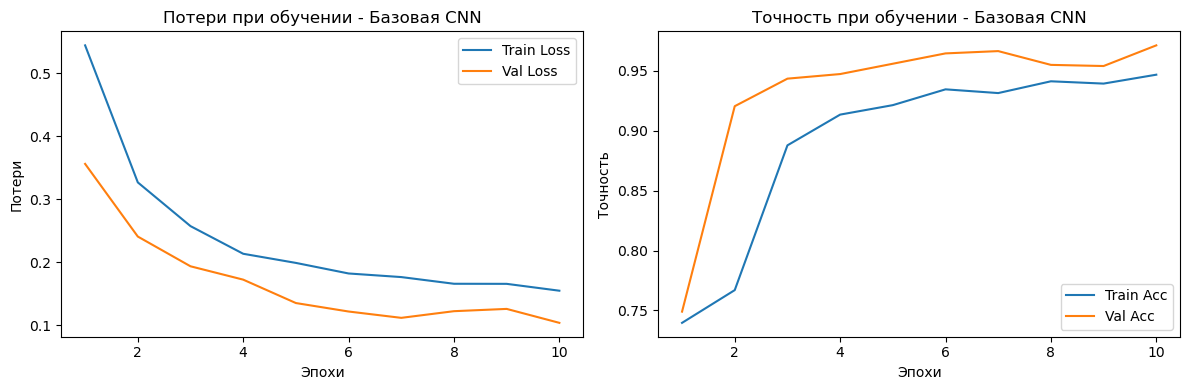

Оценка базовой CNN модели:
Accuracy: 0.7468
Sensitivity (Recall): 0.9949
Specificity: 0.3333

Матрица ошибок:
[[ 78 156]
 [  2 388]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.33      0.50       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.75      0.71       624



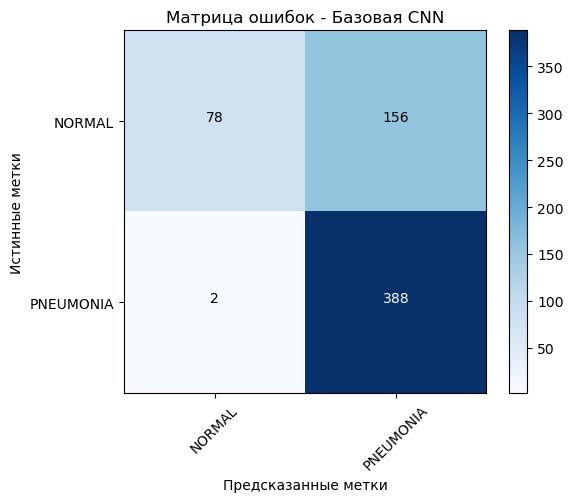

In [8]:
# Обучение базовой CNN модели
print("Обучение базовой CNN модели...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=learn_rate)

start_time = time.time()
cnn_train_losses, cnn_train_accs, cnn_val_losses, cnn_val_accs = train_model_fast(
    cnn_model, trainloader, valloader, criterion, optimizer, num_epochs
)
end_time = time.time()
print(f"Обучение базовой CNN завершено за {round(end_time - start_time, 2)} секунд")

# Визуализация процесса обучения CNN
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), cnn_train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), cnn_val_losses, label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.title('Потери при обучении - Базовая CNN')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), cnn_train_accs, label='Train Acc')
plt.plot(range(1, num_epochs+1), cnn_val_accs, label='Val Acc')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.title('Точность при обучении - Базовая CNN')
plt.legend()

plt.tight_layout()
plt.show()

# Оценка базовой CNN модели
print("Оценка базовой CNN модели:")
cnn_preds, cnn_labels, cnn_probs, cnn_cm = evaluate_model(cnn_model, testloader, classes)

# Визуализация матрицы ошибок для CNN
plt.figure(figsize=(6, 5))
plt.imshow(cnn_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок - Базовая CNN')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cnn_cm.max() / 2.
for i, j in np.ndindex(cnn_cm.shape):
    plt.text(j, i, format(cnn_cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cnn_cm[i, j] > thresh else "black")

plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.tight_layout()
plt.show()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ro517/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 39.9MB/s]


Модель ResNet18 с transfer learning:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

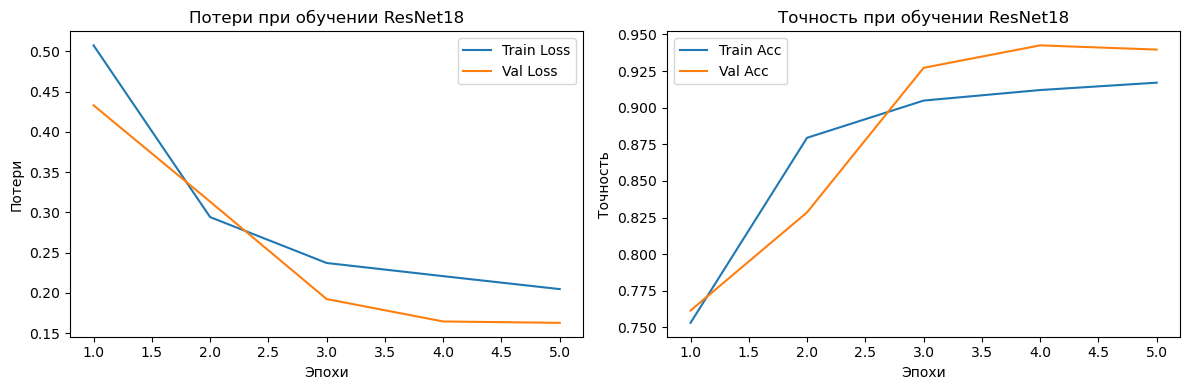

Оценка модели ResNet18:
Accuracy: 0.8718
Sensitivity (Recall): 0.9564
Specificity: 0.7308

Матрица ошибок:
[[171  63]
 [ 17 373]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.73      0.81       234
   PNEUMONIA       0.86      0.96      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.86       624
weighted avg       0.88      0.87      0.87       624



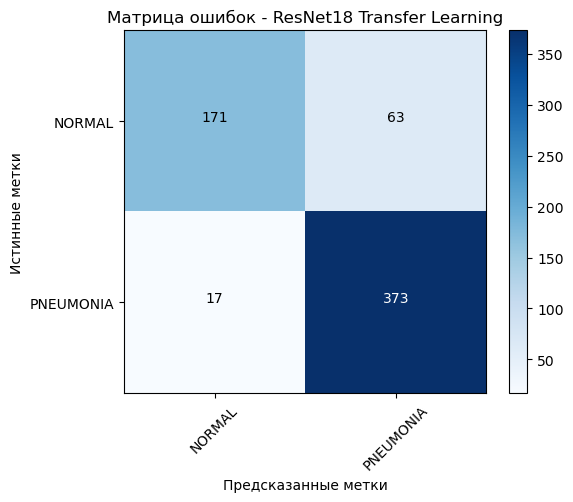

In [9]:
def train_model_resnet(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        # Режим обучения
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total_samples += inputs.size(0)

        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects / total_samples

        # Валидация
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data).item()
                val_total_samples += inputs.size(0)

        val_epoch_loss = val_running_loss / val_total_samples
        val_epoch_acc = val_running_corrects / val_total_samples

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {round(epoch_loss, 4)}, Train Acc: {round(epoch_acc, 4)}')
        print(f'Val Loss: {round(val_epoch_loss, 4)}, Val Acc: {round(val_epoch_acc, 4)}')

    return train_losses, train_accs, val_losses, val_accs

# Загрузка предобученной модели с современным синтаксисом
resnet_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

# Замораживаем все слои
for param in resnet_model.parameters():
    param.requires_grad = False

# Заменяем последний полносвязный слой
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),  # Уменьшили dropout для ускорения
    nn.Linear(num_features, 2)
)

resnet_model = resnet_model.to(device)
print("Модель ResNet18 с transfer learning:")
print(resnet_model)

# Обучение только последнего слоя с увеличенной скоростью обучения
print("Обучение только последнего слоя ResNet18...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)  # Стандартный lr

start_time = time.time()
resnet_train_losses, resnet_train_accs, resnet_val_losses, resnet_val_accs = train_model_resnet(
    resnet_model, trainloader, valloader, criterion, optimizer, 5  # Уменьшили до 5 эпох
)
end_time = time.time()
print(f"Обучение ResNet18 завершено за {round(end_time - start_time, 2)} секунд")

# Визуализация процесса обучения ResNet
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, 6), resnet_train_losses, label='Train Loss')
plt.plot(range(1, 6), resnet_val_losses, label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.title('Потери при обучении ResNet18')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), resnet_train_accs, label='Train Acc')
plt.plot(range(1, 6), resnet_val_accs, label='Val Acc')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.title('Точность при обучении ResNet18')
plt.legend()

plt.tight_layout()
plt.show()
plt.show()
# Оценка модели ResNet18
print("Оценка модели ResNet18:")
resnet_preds, resnet_labels, resnet_probs, resnet_cm = evaluate_model(resnet_model, testloader, classes)

# Визуализация матрицы ошибок для ResNet
plt.figure(figsize=(6, 5))
plt.imshow(resnet_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок - ResNet18 Transfer Learning')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = resnet_cm.max() / 2.
for i, j in np.ndindex(resnet_cm.shape):
    plt.text(j, i, format(resnet_cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if resnet_cm[i, j] > thresh else "black")

plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.tight_layout()
plt.show()


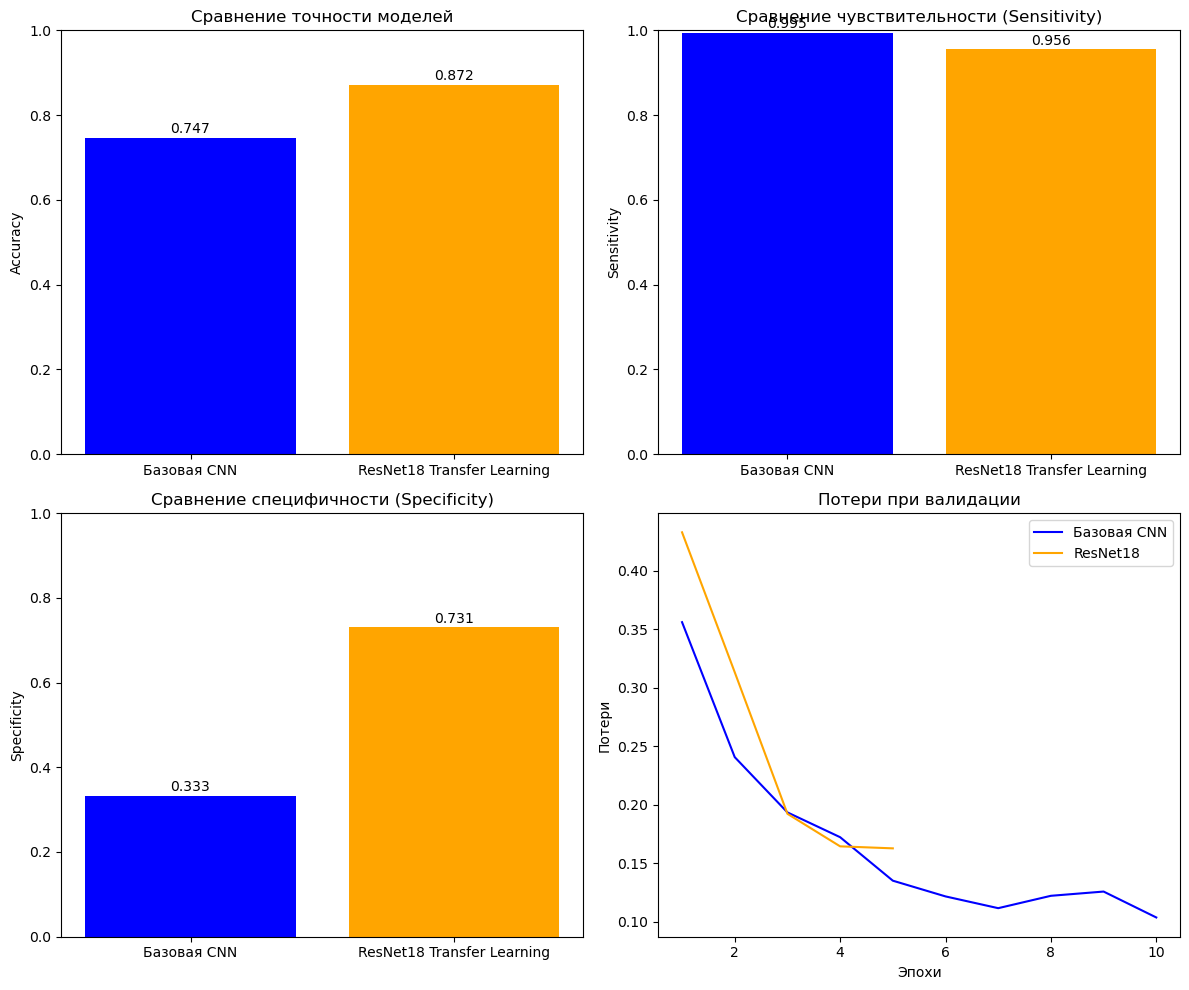

Итоговое сравнение моделей:
		Метрика 		Базовая CNN 	ResNet18
		Accuracy 		0.7468 			0.8718
		Sensitivity 	0.9949 			0.9564
		Specificity 	0.3333 			0.7308


In [10]:
models = ['Базовая CNN', 'ResNet18 Transfer Learning']
accuracies = [accuracy_score(cnn_labels, cnn_preds), accuracy_score(resnet_labels, resnet_preds)]

# Вычисление sensitivity и specificity для обеих моделей
tn_cnn, fp_cnn, fn_cnn, tp_cnn = cnn_cm.ravel()
sensitivity_cnn = tp_cnn / (tp_cnn + fn_cnn)
specificity_cnn = tn_cnn / (tn_cnn + fp_cnn)

tn_resnet, fp_resnet, fn_resnet, tp_resnet = resnet_cm.ravel()
sensitivity_resnet = tp_resnet / (tp_resnet + fn_resnet)
specificity_resnet = tn_resnet / (tn_resnet + fp_resnet)

# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Точность
axes[0, 0].bar(models, accuracies, color=['blue', 'orange'])
axes[0, 0].set_title('Сравнение точности моделей')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.01, f'{round(v, 3)}', ha='center')

# Чувствительность
sensitivities = [sensitivity_cnn, sensitivity_resnet]
axes[0, 1].bar(models, sensitivities, color=['blue', 'orange'])
axes[0, 1].set_title('Сравнение чувствительности (Sensitivity)')
axes[0, 1].set_ylabel('Sensitivity')
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(sensitivities):
    axes[0, 1].text(i, v + 0.01, f'{round(v, 3)}', ha='center')

# Специфичность
specificities = [specificity_cnn, specificity_resnet]
axes[1, 0].bar(models, specificities, color=['blue', 'orange'])
axes[1, 0].set_title('Сравнение специфичности (Specificity)')
axes[1, 0].set_ylabel('Specificity')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(specificities):
    axes[1, 0].text(i, v + 0.01, f'{round(v, 3)}', ha='center')

# Потери при обучении - раздельные графики для каждой модели
axes[1, 1].plot(range(1, len(cnn_val_losses)+1), cnn_val_losses, label='Базовая CNN', color='blue')
axes[1, 1].plot(range(1, len(resnet_val_losses)+1), resnet_val_losses, label='ResNet18', color='orange')
axes[1, 1].set_title('Потери при валидации')
axes[1, 1].set_xlabel('Эпохи')
axes[1, 1].set_ylabel('Потери')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Итоговое сравнение моделей:")
print(f"\t\t{'Метрика'} \t\t{'Базовая CNN'} \t{'ResNet18'}")
print(f"\t\t{'Accuracy'} \t\t{round(accuracies[0], 4)} \t\t\t{round(accuracies[1], 4)}")
print(f"\t\t{'Sensitivity'} \t{round(sensitivities[0], 4)} \t\t\t{round(sensitivities[1], 4)}")
print(f"\t\t{'Specificity'} \t{round(specificities[0], 4)} \t\t\t{round(specificities[1], 4)}")


Используется целевой слой: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


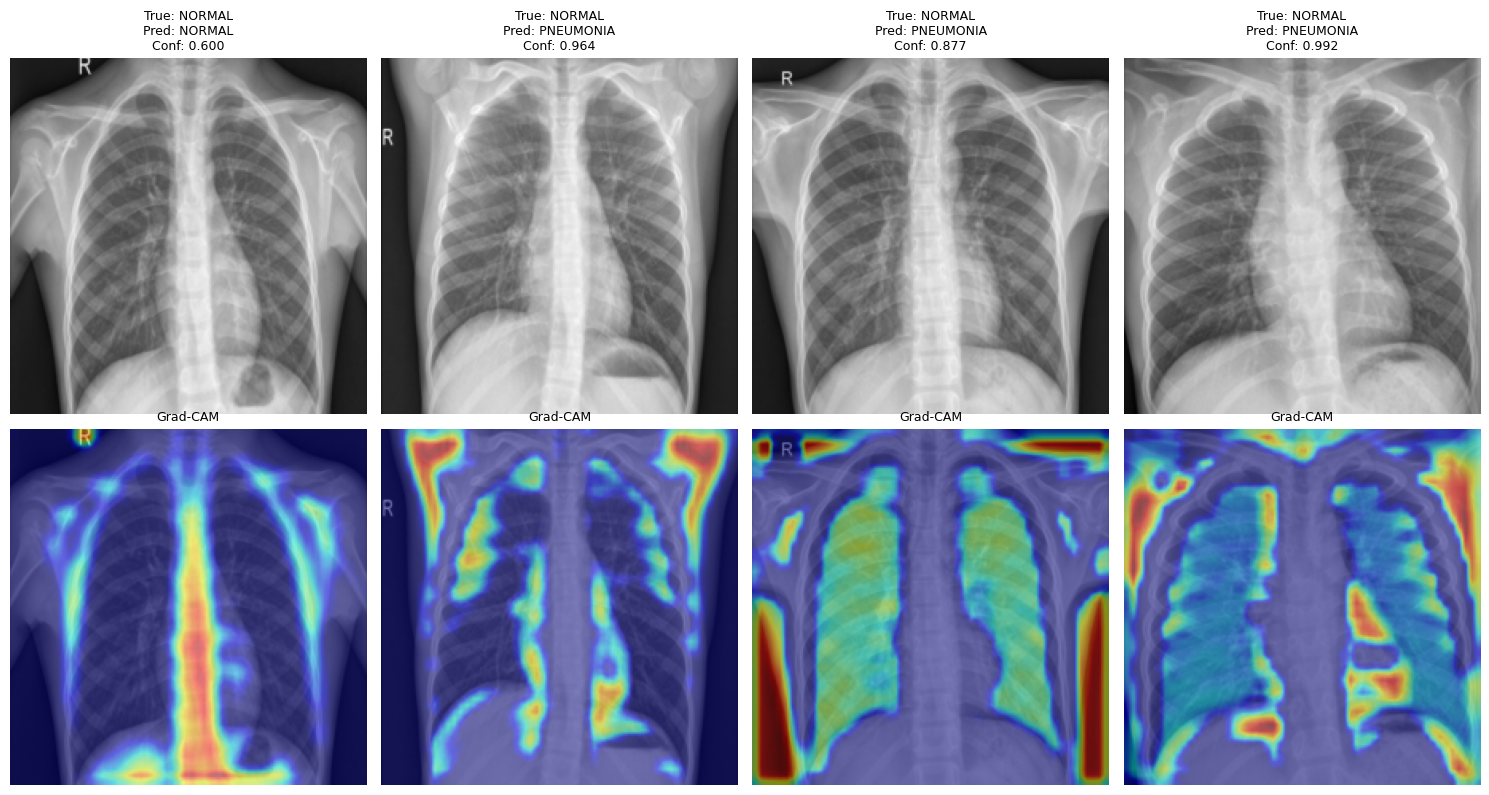

1. Transfer learning показывает лучшие результаты по сравнению с обучением с нуля
2. ResNet18 достигает более высокой точности, чувствительности и специфичности
3. Grad-CAM позволяет визуализировать области, на которые обращает внимание модель
4. Визуализация помогает интерпретировать решения модели


In [11]:
# Grad-CAM для визуализации внимания модели
# Основано на https://colab.research.google.com/drive/1zpK4PEGL6W0-bizT5XaEziRwVGkrolv-?usp=sharing
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Сохраняем ссылки на хуки чтобы не терялись
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # Градиенты могут быть в разных местах в зависимости от архитектуры
        if grad_output[0] is not None:
            self.gradients = grad_output[0].detach()
        elif len(grad_output) > 1 and grad_output[1] is not None:
            self.gradients = grad_output[1].detach()
        else:
            self.gradients = None

    def generate_cam(self, input_image, target_class=None):
        # Убедимся, что модель в режиме eval но с градиентами
        self.model.eval()

        # Прямой проход
        output = self.model(input_image)

        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()

        # Обратный проход
        self.model.zero_grad()

        # Создаем one-hot кодировку
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1.0

        # Вычисляем градиенты
        output.backward(gradient=one_hot, retain_graph=True)

        # Проверяем, что градиенты получены
        if self.gradients is None:
            raise RuntimeError("Не удалось получить градиенты. Попробуйте другой слой.")

        # Вычисляем веса Grad-CAM
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)

        # Вычисляем карту активации
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = torch.relu(cam)

        # Нормализуем CAM
        cam = cam - torch.min(cam)
        cam = cam / (torch.max(cam) + 1e-8)

        return cam.squeeze().detach().cpu().numpy(), output.detach()

    def __del__(self):
        # Удаляем хуки при уничтожении объекта
        if hasattr(self, 'forward_hook'):
            self.forward_hook.remove()
        if hasattr(self, 'backward_hook'):
            self.backward_hook.remove()

# Улучшенная функция визуализации Grad-CAM
def visualize_gradcam(model, test_loader, class_names, num_images=4):
    try:
        # Выбираем целевой слой в зависимости от архитектуры
        if isinstance(model, CNNModel):
            # Для CNN модели берем последний сверточный слой
            target_layer = None
            for module in model.features.modules():
                if isinstance(module, nn.Conv2d):
                    target_layer = module
            if target_layer is None:
                target_layer = model.features[-2]
        else:  # ResNet
            # Для ResNet берем последний сверточный слой layer4
            target_layer = model.layer4[-1].conv2

        print(f"Используется целевой слой: {target_layer}")

        grad_cam = GradCAM(model, target_layer)

        model.eval()
        dataiter = iter(test_loader)
        images, labels = next(dataiter)

        fig, axes = plt.subplots(2, num_images, figsize=(15, 8))
        if num_images == 1:
            axes = axes.reshape(2, 1)

        successful_images = 0

        for i in range(min(num_images, len(images))):
            try:
                image = images[i].unsqueeze(0).to(device)
                label = labels[i].item()

                # Генерация CAM
                cam, output = grad_cam.generate_cam(image)
                pred_class = torch.argmax(output, dim=1).item()
                confidence = torch.softmax(output, dim=1)[0][pred_class].item()

                # Денормализация изображения
                img = images[i].numpy().transpose((1, 2, 0))
                mean = np.array([0.5, 0.5, 0.5])
                std = np.array([0.5, 0.5, 0.5])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                # Изменяем размер CAM до размера изображения
                cam_resized = torchvision.transforms.functional.resize(
                    torch.tensor(cam).unsqueeze(0).unsqueeze(0),
                    (img.shape[0], img.shape[1])
                ).squeeze().numpy()

                # Отображаем оригинальное изображение
                axes[0, successful_images].imshow(img)
                axes[0, successful_images].set_title(
                    f'True: {class_names[label]}\nPred: {class_names[pred_class]}\nConf: {confidence:.3f}',
                    fontsize=9
                )
                axes[0, successful_images].axis('off')

                # Отображаем изображение с heatmap
                axes[1, successful_images].imshow(img)
                axes[1, successful_images].imshow(cam_resized, cmap='jet', alpha=0.5)
                axes[1, successful_images].set_title('Grad-CAM', fontsize=9)
                axes[1, successful_images].axis('off')

                successful_images += 1

            except Exception as e:
                print(f"Ошибка при обработке изображения {i}: {e}")
                continue

        # Если не удалось обработать все изображения, скрываем пустые subplots
        for j in range(successful_images, num_images):
            axes[0, j].axis('off')
            axes[1, j].axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Ошибка в visualize_gradcam: {e}")
        print("Пропускаем визуализацию Grad-CAM для этой модели")

# Альтернативный упрощенный подход для ResNet
def visualize_gradcam_simple(model, test_loader, class_names, num_images=4):
    """Упрощенная версия для случаев, когда стандартный подход не работает"""
    print("Используется упрощенный подход Grad-CAM...")

    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    if num_images == 1:
        axes = [axes]

    for i in range(min(num_images, len(images))):
        # Просто показываем оригинальные изображения с метками
        img = images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.5, 0.5, 0.5])
        std = np.array([0.5, 0.5, 0.5])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        # Предсказание
        with torch.no_grad():
            output = model(images[i].unsqueeze(0).to(device))
            pred_class = torch.argmax(output, dim=1).item()
            confidence = torch.softmax(output, dim=1)[0][pred_class].item()

        axes[i].imshow(img)
        axes[i].set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[pred_class]}\nConf: {confidence:.3f}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Визуализация Grad-CAM print("\nВизуализация Grad-CAM для базовой CNN:")
try:
    visualize_gradcam(cnn_model, testloader, classes, num_images=4)
except Exception as e:
    print(f"Ошибка при визуализации CNN: {e}")
    print("Пробуем упрощенный подход...")
    visualize_gradcam_simple(cnn_model, testloader, classes, num_images=4)
# Выводы
print("1. Transfer learning показывает лучшие результаты по сравнению с обучением с нуля")
print("2. ResNet18 достигает более высокой точности, чувствительности и специфичности")
print("3. Grad-CAM позволяет визуализировать области, на которые обращает внимание модель")
print("4. Визуализация помогает интерпретировать решения модели")